**AB Test project**

In [2]:
import kagglehub

# Download latest version
download_path = kagglehub.dataset_download("adarsh0806/ab-testing-practice")

print("Path to dataset files:", download_path)

c:\Users\User\Documents\PythonScripts\ABtest_project\abtest\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\adarsh0806\ab-testing-practice\versions\1


In [46]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

**User ID** - id пользователя

**Group** - к какой группе принадлежит пользователь

**Page views** - количество просмотренных пользователем страниц за сессию

**Time Spent** - время сессии (в секундах)

**Conversion** - конверсия:)

**Device** - устройство, с которого произошел вход

**Location** - страна, из которой был произведен вход

In [ ]:
file_path = Path(download_path)/"ab_testing.csv"
ab_test = pd.read_csv(file_path)
print('Dataset size:', ab_test.shape)
display(ab_test.head(5))

# Проверка на наличие NULL-значений
display(ab_test.isna().any())

Dataset size: (5000, 7)


,User ID,Group,Page Views,Time Spent,Conversion,Device,Location
0,14292,B,3,424,No,Mobile,Northern Ireland
1,11682,A,9,342,No,Mobile,Scotland
2,19825,A,2,396,No,Desktop,Northern Ireland
3,16080,B,4,318,No,Desktop,Wales
4,18851,A,1,338,Yes,Desktop,Scotland


User ID       False
Group         False
Page Views    False
Time Spent    False
Conversion    False
Device        False
Location      False
dtype: bool

In [12]:
# Посмотрим, как распределены время сессии для пользователей телефонов и PC
print(ab_test['Group'].value_counts())

# Распределение по группам и локациям
print('\n', ab_test.groupby(by = ['Group', 'Location']).size())

Group
A    2519
B    2481
Name: count, dtype: int64

 Group  Location        
A      England             606
       Northern Ireland    614
       Scotland            670
       Wales               629
B      England             640
       Northern Ireland    628
       Scotland            611
       Wales               602
dtype: int64


**Гипотезы**:

1. Увеличение среднего количества просмотренных пользователем страниц за сессию (увеличение вовлеченности пользователя). $H_0$: $\mu_A = \mu_B$, альтернатива $H_1$: $\mu_A < \mu_B$

2. Увеличение среднего времени сессии (отдельно для мобильных и PC версий сайта). $H_0$: $\mu_A = \mu_B$, альтернатива $H_1$: $\mu_A < \mu_B$

3. Увеличение положительной конверсии. $H_0$: гипотеза однородности, $H_1$: конверсия увеличилась


**Проверка гипотез**:

1. t-критерий Стьюдента

2. t-критерий Стьюдента

3. Критерий $\chi^2$ Пирсона

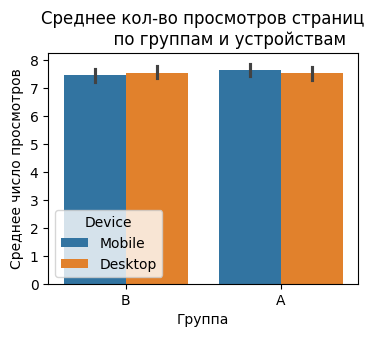

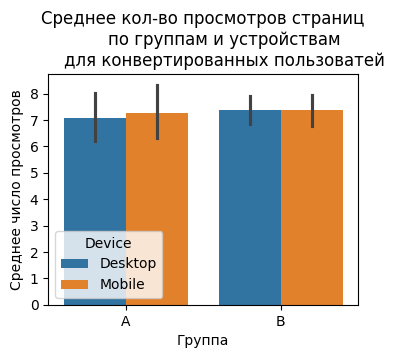

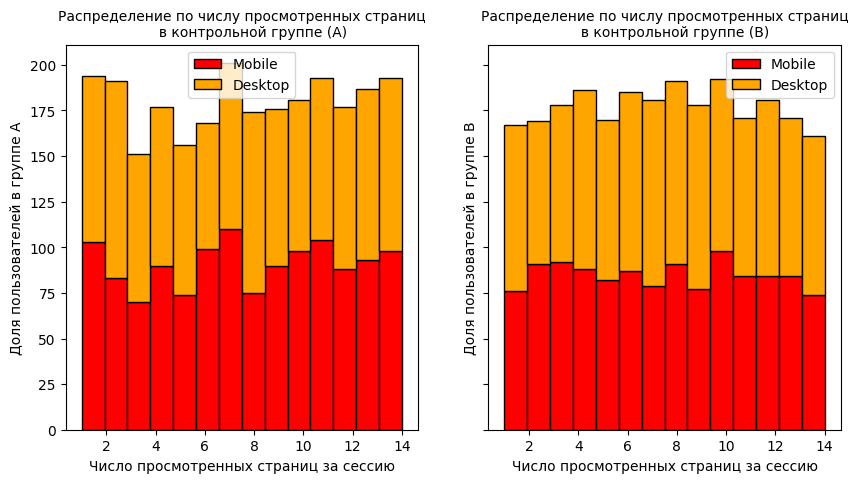

In [65]:
# Проверка первой гипотезы

# Выявляем закономерности, связанные с устройством, с которого выполнен вход
plt.figure(figsize=(4, 3))
sns.barplot(data=ab_test, x='Group', y='Page Views', hue='Device')

plt.title('''Среднее кол-во просмотров страниц
          по группам и устройствам''')
plt.yticks(np.arange(0, 9, 1))
plt.ylabel('Среднее число просмотров')
plt.xlabel('Группа')

# Строим тот же barplot, только для конвертированных пользователей
plt.figure(figsize=(4, 3))
sns.barplot(data=ab_test.loc[ab_test['Conversion'] == 'Yes'], x='Group', y='Page Views', hue='Device')

plt.title('''Среднее кол-во просмотров страниц
        по группам и устройствам
        для конвертированных пользоватей''')
plt.yticks(np.arange(0, 9, 1))
plt.ylabel('Среднее число просмотров')
plt.xlabel('Группа')

# Смотрим на распределения
a_group_mobile_avg_views = ab_test.loc[(ab_test['Group'] == 'A') &\
                                        (ab_test['Device'] == 'Mobile')]['Page Views']
a_group_pc_avg_views = ab_test.loc[(ab_test['Group'] == 'A') &\
                                        (ab_test['Device'] == 'Desktop')]['Page Views']

b_group_mobile_avg_views = ab_test.loc[(ab_test['Group'] == 'B') &\
                                       (ab_test['Device'] == 'Mobile')]['Page Views']
b_group_pc_avg_views = ab_test.loc[(ab_test['Group'] == 'B') &\
                                       (ab_test['Device'] == 'Desktop')]['Page Views']


# Смотрим на распределения
fig, ax = plt.subplots(nrows = 1, ncols = 2, sharey = True, figsize = (10, 5))

ax[0].hist([a_group_mobile_avg_views, a_group_pc_avg_views], stacked = True, bins = 14,
        color = ['red', 'orange'], alpha = 1., edgecolor = 'black',
        label = ['Mobile', 'Desktop'], density = False)
ax[0].set_title('''Распределение по числу просмотренных страниц
     в контрольной группе (A)''', fontsize = 10)
ax[0].set_xlabel('Число просмотренных страниц за сессию')
ax[0].set_ylabel('Доля пользователей в группе A')
ax[0].legend()

ax[1].hist([b_group_mobile_avg_views, b_group_pc_avg_views], stacked = True, bins = 14,
        color = ['red', 'orange'], alpha = 1., edgecolor = 'black',
        label = ['Mobile', 'Desktop'], density = False)
ax[1].set_title('''Распределение по числу просмотренных страниц
     в контрольной группе (B)''', fontsize = 10)
ax[1].set_xlabel('Число просмотренных страниц за сессию')
ax[1].set_ylabel('Доля пользователей в группе B')
ax[1].legend()
plt.show()

Group  Device 
A      Desktop    243.131029
       Mobile     240.369412
B      Desktop    243.238022
       Mobile     243.375737
Name: Time Spent, dtype: float64 



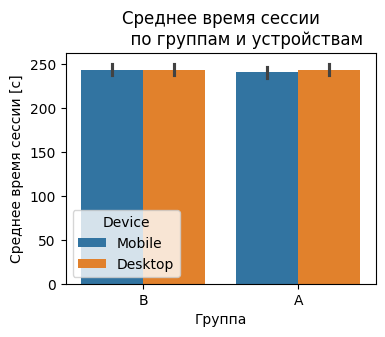

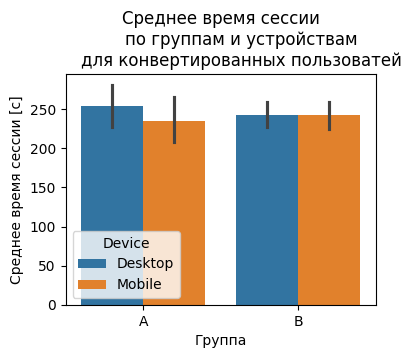

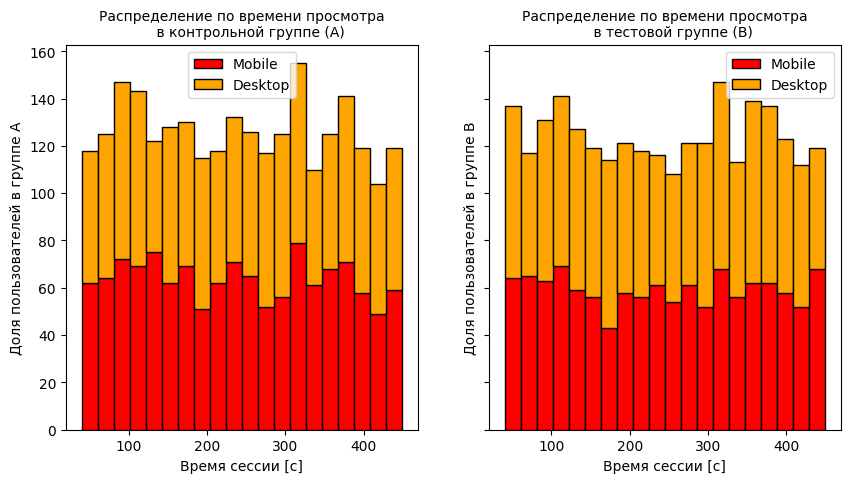

In [67]:
# Проверка второй гипотезы

# Выявляем закономерности, связанные с устройством, с которого выполнен вход
plt.figure(figsize=(4, 3))
sns.barplot(data=ab_test, x='Group', y='Time Spent', hue='Device')

plt.title('''Среднее время сессии
          по группам и устройствам''')
plt.ylabel('Среднее время сессии [с]')
plt.xlabel('Группа')

# Строим тот же barplot, только для конвертированных пользователей
plt.figure(figsize=(4, 3))
sns.barplot(data=ab_test.loc[ab_test['Conversion'] == 'Yes'], x='Group', y='Time Spent', hue='Device')

plt.title('''Среднее время сессии
        по группам и устройствам
        для конвертированных пользоватей''')
plt.ylabel('Среднее время сессии [с]')
plt.xlabel('Группа')

# Распределяем время сессии по группам и устройствам
print(ab_test.groupby(by = ['Group', 'Device'])['Time Spent'].mean(), '\n')

a_group_mobile_avg_time = ab_test.loc[(ab_test['Group'] == 'A') &\
                                        (ab_test['Device'] == 'Mobile')]['Time Spent']
a_group_pc_avg_time = ab_test.loc[(ab_test['Group'] == 'A') &\
                                        (ab_test['Device'] == 'Desktop')]['Time Spent']

b_group_mobile_avg_time = ab_test.loc[(ab_test['Group'] == 'B') &\
                                       (ab_test['Device'] == 'Mobile')]['Time Spent']
b_group_pc_avg_time = ab_test.loc[(ab_test['Group'] == 'B') &\
                                       (ab_test['Device'] == 'Desktop')]['Time Spent']

# Строим распределение
fig, ax = plt.subplots(nrows = 1, ncols = 2, sharey = True, figsize = (10, 5))

ax[0].hist([a_group_mobile_avg_time, a_group_pc_avg_time], stacked = True, bins = 20,
        color = ['red', 'orange'], alpha = 1., edgecolor = 'black',
        label = ['Mobile', 'Desktop'], density = False)
ax[0].set_title('''Распределение по времени просмотра
    в контрольной группе (A)''', fontsize = 10)
ax[0].set_xlabel('Время сессии [с]')
ax[0].set_ylabel('Доля пользователей в группе A')
ax[0].legend()

ax[1].hist([b_group_mobile_avg_time, b_group_pc_avg_time], stacked = True, bins = 20,
        color = ['red', 'orange'], alpha = 1., edgecolor = 'black',
        label = ['Mobile', 'Desktop'], density = False)
ax[1].set_title('''Распределение по времени просмотра
    в тестовой группе (B)''', fontsize = 10)
ax[1].set_xlabel('Время сессии [с]')
ax[1].set_ylabel('Доля пользователей в группе B')
ax[1].legend(loc = 'upper right')
plt.show()

In [8]:
# Проверка третьей гипотезы

# Составляем таблицу сопряженности
contingency_table = pd.crosstab(ab_test['Group'], ab_test['Conversion'])
display(contingency_table)

# Находим p-value для гипотезы
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(contingency_table, correction = True)
print(f'p-value: {p:.1e}')

Conversion,No,Yes
Group,,
A,2383,136
B,2132,349


p-value: 6.6e-25
